In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.colorbar import Colorbar
from matplotlib import colors
from scipy import special
from mycolorpy import colorlist as mcp
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import pandas as pd


plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{xcolor}"
plt.rcParams["font.family"] = "lmodern"

In [6]:
cwd = Path().resolve()
project_root = cwd.parent

data_equilibrium_dir = project_root / "data" / "equilibrium"
data_quench_dir = project_root / "data" / "quench" / "quench_paper"
plot_dir = project_root / "plot"/"figures"/"figures_paper"

In [47]:
def plot_SSH_and_RM_free_gapped_to_gapless_no_flux():
    # Load data 
    df_SSH = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapped_to_gapless_v99999_L100cells_200sec.csv")
    df_RM = pd.read_csv(data_quench_dir / "run_RM_free_quench_gapped_to_gapless_v99999_L100cells_200sec.csv")

    # Extract data
    time_SSH = df_SSH["Time"].values
    entropy_SSH = df_SSH["Entropy"].values
    variance_SSH = df_SSH["Variance"].values

    time_RM = df_RM["Time"].values
    entropy_RM = df_RM["Entropy"].values
    variance_RM = df_RM["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(10, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])
    ax4 = ax3.twinx()
    
    # SSH Plot
    l1, =ax1.plot(time_SSH, entropy_SSH, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time_SSH, variance_SSH, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"SSH Quench from Gapped to Gapless Phase (No Flux)", size=18)
    ax1.text(0.3, 0.1, r"Pre-quench $\text{Gap}_{\text{SSH}} = 2 \vert v-w \vert = 1w$", transform=ax1.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")

    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)

    # RM Plot
    l3, = ax3.plot(time_RM, entropy_RM, color="red", label=r"Entanglement Entropy")
    l4, = ax4.plot(time_RM, variance_RM, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax3.set_xlabel(r"Time $\tau$", size=16)
    ax3.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax4.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax3.tick_params(axis="y", labelcolor="red")
    ax4.tick_params(axis="y", labelcolor="cornflowerblue")
    ax3.set_title(r"RM Quench from Gapped to Gapless Phase (No Flux)", size=18)
    ax3.text(0.3, 0.1, r"Pre-quench $\text{Gap}_{\text{RM}} = 2 \vert \Delta \vert = 1w$", transform=ax3.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")

    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax3.legend(handles=[l3, l4], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "SSH_and_RM_free_quench_gapped_to_gapless_no_flux.pdf")
    plt.show()

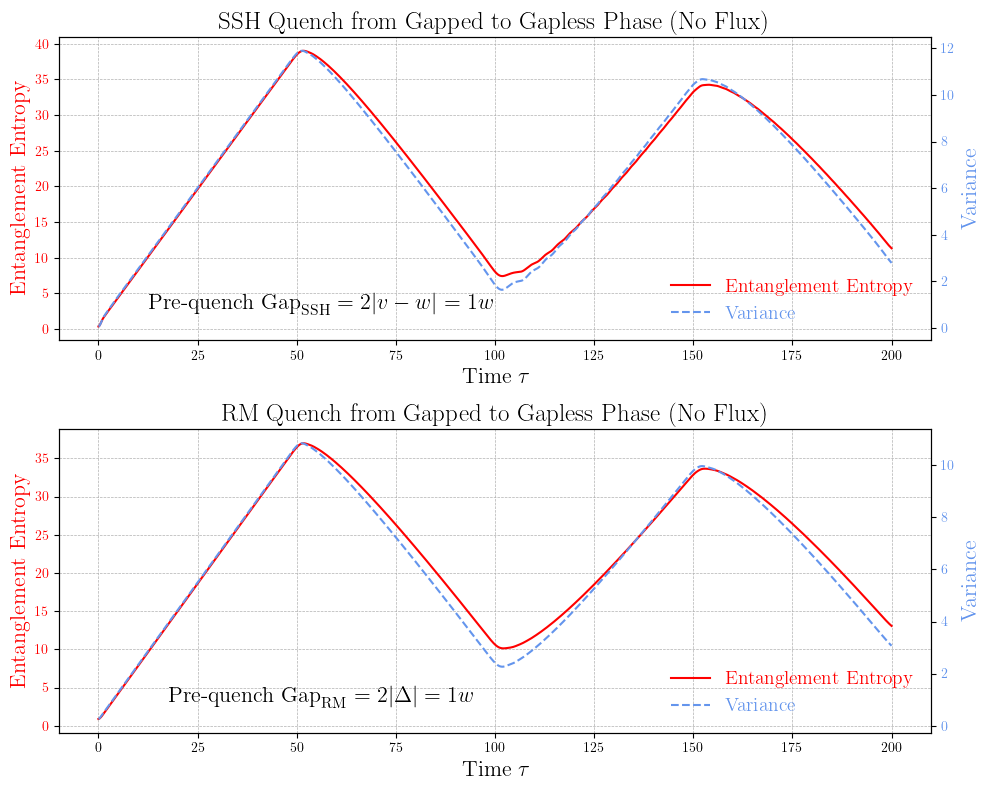

In [48]:
plot_SSH_and_RM_free_gapped_to_gapless_no_flux()

In [49]:
def plot_quench_gapless_with_flux_to_gapless_without_flux():
    df = pd.read_csv(data_quench_dir / "run_TB_free_quench_gapless_with_flux_to_gapless_no_flux_L100cells_200sec_v99999.csv")

    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()
    l1, = ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Gapless with Flux to Gapless without Flux", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)

    plt.tight_layout()
    plt.savefig(plot_dir / "TB_free_quench_gapless_with_flux_to_gapless_no_flux.pdf")
    plt.show()

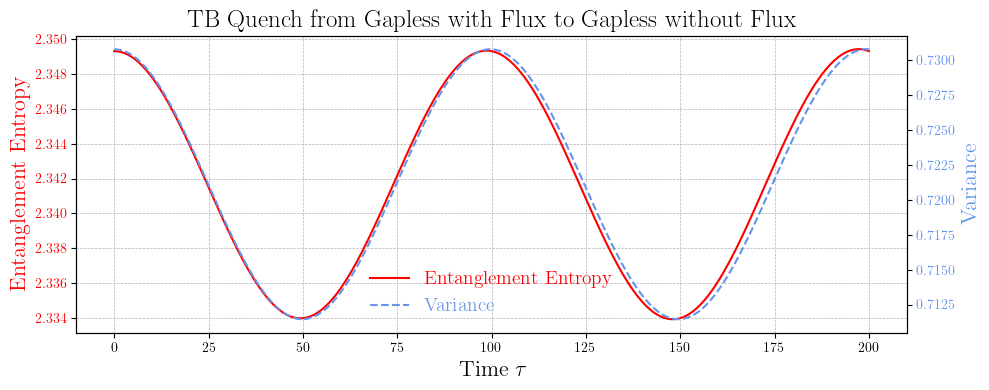

In [50]:
plot_quench_gapless_with_flux_to_gapless_without_flux()

In [9]:
def plot_SSH_free_quench_gapless_with_flux_to_gapless_no_flux():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapless_with_flux_to_gapless_no_flux_L100cells_200sec_v99999.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"SSH Quench from Gapless with Flux to Gapless without Flux", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "SSH_free_quench_gapless_with_flux_to_gapless_no_flux.pdf")
    plt.show()

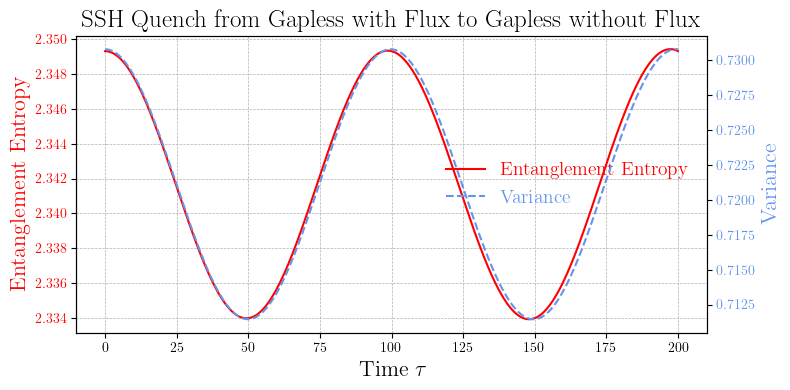

In [10]:
plot_SSH_free_quench_gapless_with_flux_to_gapless_no_flux()

In [11]:
def plot_RM_free_quench_gapped_to_gapless_no_flux():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_RM_free_quench_gapped_to_gapless_v99999_L100cells_200sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"RM Quench from Gapped to Gapless Phase (No Flux)", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "RM_free_quench_gapped_to_gapless_no_flux.pdf")
    plt.show()

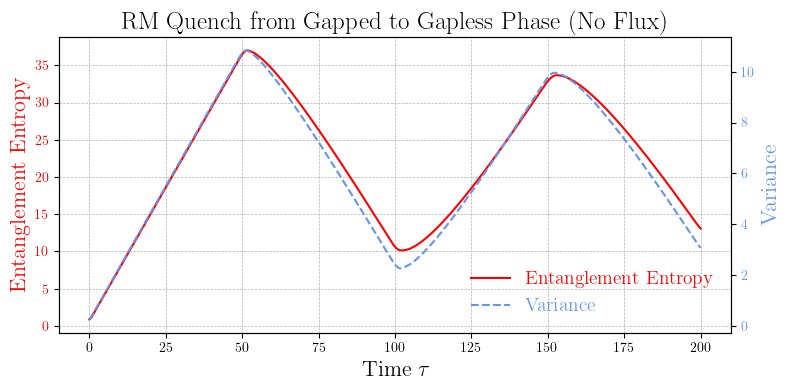

In [12]:
plot_RM_free_quench_gapped_to_gapless_no_flux()

In [13]:
def plot_TB_quench_interacting_gapped_to_non_interacting_gapless():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_TB_quench_interacting_gapped_to_non_interacting_gapless_SSH_200sites_10sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Interacting Gapped to Non-Interacting Gapless Phase",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "TB_quench_interacting_gapped_to_non_interacting_gapless.pdf")
    plt.show()

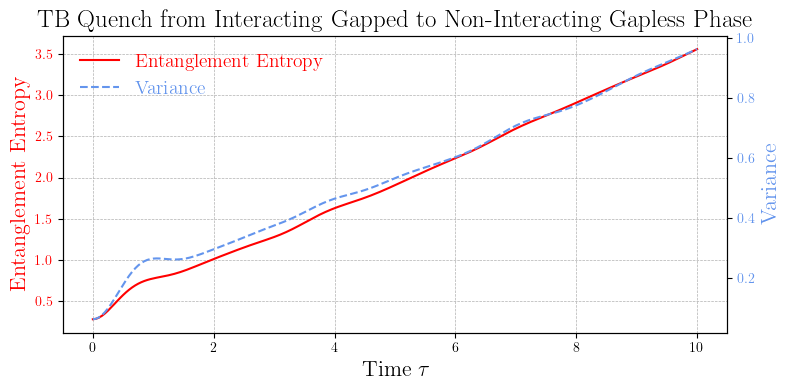

In [14]:
plot_TB_quench_interacting_gapped_to_non_interacting_gapless()

In [15]:
def plot_TB_quench_interacting_gapless_to_non_interacting_gapless():
    # Load data 
    df = pd.read_csv(data_quench_dir / "run_TB_quench_interacting_gapless_to_non_interacting_gapless_SSH_200sites_10sec.csv")

    # Extract data
    time = df["Time"].values
    entropy = df["Entropy"].values
    variance = df["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(8, 4))
    spec = gridspec.GridSpec(ncols=1, nrows=1, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()

    l1, =ax1.plot(time, entropy, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time, variance, color="cornflowerblue", label=r"Variance", linestyle="--")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Interacting Gapless to Non-Interacting Gapless Phase",size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    

    plt.tight_layout()
    plt.savefig(plot_dir / "TB_quench_interacting_gapless_to_non_interacting_gapless.pdf")
    plt.show()

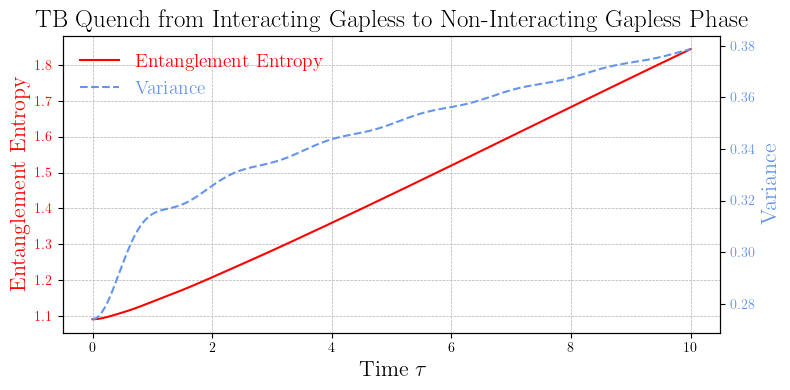

In [16]:
plot_TB_quench_interacting_gapless_to_non_interacting_gapless()

# Post-quench GAPPED

In [34]:
def plot_TB_quench_gapless_no_flux_to_RM_and_SSH_gapped_no_flux():
    # Load data
    df_SSH = pd.read_csv(data_quench_dir / "run_TB_free_quench_gapless_no_flux_to_SSH_gapped_no_flux_L100cells_200sec.csv")
    df_RM = pd.read_csv(data_quench_dir / "run_TB_free_quench_gapless_no_flux_to_RM_gapped_no_flux_L100cells_200sec.csv")

    # Extract data
    time_SSH = df_SSH["Time"].values
    entropy_SSH = df_SSH["Entropy"].values
    variance_SSH = df_SSH["Variance"].values
    time_RM = df_RM["Time"].values
    entropy_RM = df_RM["Entropy"].values
    variance_RM = df_RM["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(10, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])
    ax4 = ax3.twinx()

    # SSH Plot - ax1 and ax2
    l1, =ax1.plot(time_SSH, entropy_SSH, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time_SSH, variance_SSH, color="cornflowerblue", label=r"Variance")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"TB Quench from Gapless without Flux to SSH Gapped without Flux", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax1.text(0.5, 0.1, r"Post-quench $\text{Gap}_{\text{SSH}} = 2 \vert v-w \vert = 1w$", transform=ax1.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    leg1 = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg1.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)

    # RM Plot - ax3 and ax4
    l3, =ax3.plot(time_RM, entropy_RM, color="red", label=r"Entanglement Entropy")
    l4, = ax4.plot(time_RM, variance_RM, color="cornflowerblue", label=r"Variance")
    ax3.set_xlabel(r"Time $\tau$", size=16)
    ax3.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax4.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax3.tick_params(axis="y", labelcolor="red")
    ax4.tick_params(axis="y", labelcolor="cornflowerblue")
    ax3.set_title(r"TB Quench from Gapless without Flux to RM Gapped without Flux", size=18)
    ax3.text(0.5, 0.1, r"Post-quench $\text{Gap}_{\text{RM}} = 2 \vert \Delta \vert = 1w$", transform=ax3.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg2 = ax3.legend(handles=[l3, l4], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg2.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    
    plt.tight_layout()
    plt.savefig(plot_dir / "TB_quench_gapless_no_flux_to_RM_and_SSH_gapped_no_flux.pdf")
    plt.show()

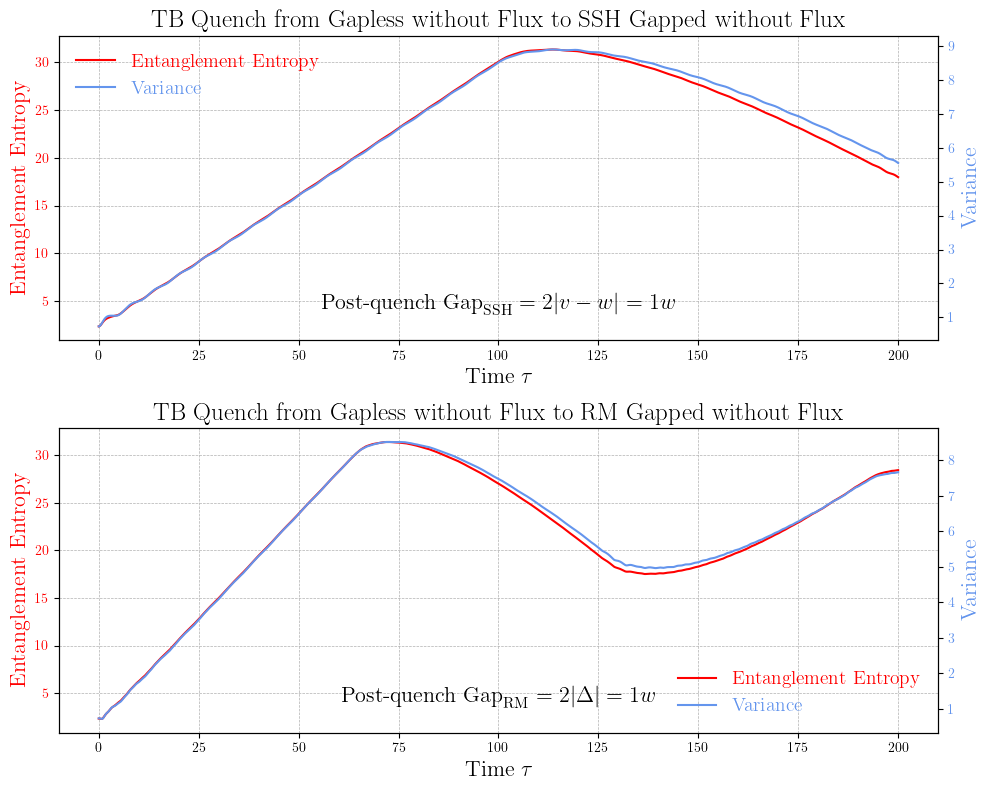

In [35]:
plot_TB_quench_gapless_no_flux_to_RM_and_SSH_gapped_no_flux()

In [36]:
def plot_RM_and_SSH_free_gapped_with_flux_to_gapped_no_flux():
    # Load data 
    df_SSH = pd.read_csv(data_quench_dir / "run_SSH_free_quench_gapped_with_flux_to_gapped_no_flux_L100cells_200sec.csv")
    df_RM = pd.read_csv(data_quench_dir / "run_RM_free_quench_gapped_with_flux_to_gapped_no_flux_L100cells_200sec.csv")

    # Extract data
    time_SSH = df_SSH["Time"].values
    entropy_SSH = df_SSH["Entropy"].values
    variance_SSH = df_SSH["Variance"].values

    time_RM = df_RM["Time"].values
    entropy_RM = df_RM["Entropy"].values
    variance_RM = df_RM["Variance"].values

    # Plotting
    fig = plt.figure(figsize=(10, 8))
    spec = gridspec.GridSpec(ncols=1, nrows=2, figure=fig)
    ax1 = fig.add_subplot(spec[0, 0])
    ax2 = ax1.twinx()
    ax3 = fig.add_subplot(spec[1, 0])
    ax4 = ax3.twinx()

    # SSH Plot - ax1 and ax2
    l1, =ax1.plot(time_SSH, entropy_SSH, color="red", label=r"Entanglement Entropy")
    l2, = ax2.plot(time_SSH, variance_SSH, color="cornflowerblue", label=r"Variance")
    ax1.set_xlabel(r"Time $\tau$", size=16)
    ax1.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax2.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax1.tick_params(axis="y", labelcolor="red")
    ax2.tick_params(axis="y", labelcolor="cornflowerblue")
    ax1.set_title(r"SSH Quench from Gapped with Flux to Gapped without Flux", size=18)
    ax1.grid(True, which="both", linestyle="--", linewidth=0.5)
    ax1.text(0.5, 0.1, r"$\text{Gap}_{\text{SSH}} = 2 \vert v-w \vert = 1w$", transform=ax1.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    leg1 = ax1.legend(handles=[l1, l2], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg1.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)
    
    # RM Plot - ax3 and ax4
    l3, =ax3.plot(time_RM, entropy_RM, color="red", label=r"Entanglement Entropy")
    l4, = ax4.plot(time_RM, variance_RM, color="cornflowerblue", label=r"Variance")
    ax3.set_xlabel(r"Time $\tau$", size=16)
    ax3.set_ylabel(r"Entanglement Entropy", color="red", size=16)
    ax4.set_ylabel(r"Variance", color="cornflowerblue", size=16)
    ax3.tick_params(axis="y", labelcolor="red")
    ax4.tick_params(axis="y", labelcolor="cornflowerblue")
    ax3.set_title(r"RM Quench from Gapped with Flux to Gapped without Flux", size=18)
    ax3.text(0.5, 0.1, r"$\text{Gap}_{\text{RM}} = 2 \vert \Delta \vert = 1w$", transform=ax3.transAxes, fontsize=16, fontweight="bold", color="black", ha="center")
    ax3.grid(True, which="both", linestyle="--", linewidth=0.5)
    leg2 = ax3.legend(handles=[l3, l4], loc="best", fontsize=14, frameon=False)
    for text, color in zip(leg2.get_texts(), ["red", "cornflowerblue"]):
        text.set_color(color)

    plt.tight_layout()
    plt.savefig(plot_dir / "RM_and_SSH_free_quench_gapped_with_flux_to_gapped_no_flux.pdf")
    plt.show()

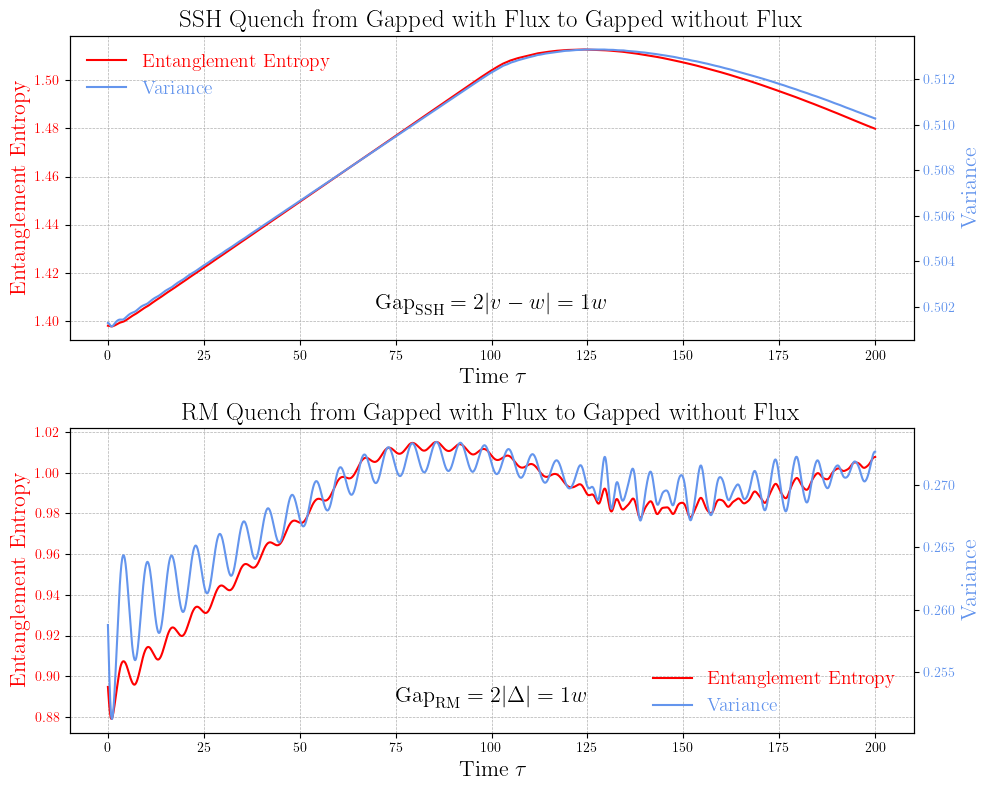

In [37]:
plot_RM_and_SSH_free_gapped_with_flux_to_gapped_no_flux()